<a href="https://colab.research.google.com/github/Hemang-Dave/ML-and-Deep-Learning/blob/DS%2FML/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
movies = pd.read_csv('/content/moviesData.csv')
df = pd.read_csv('/content/train.csv')
df.shape

(1028, 34)

In [5]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,ID
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,0,8,0,1,6,4,0,5,0
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,1,10,3,3,10,7,1,7,1
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,0,7,3,3,0,0,0,0,2
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,0,8,3,3,8,7,3,0,3
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,1,6,3,3,2,2,2,2,4
5,32,0,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,0,8,2,2,7,7,3,6,5
6,59,0,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,3,12,3,2,1,0,0,0,6
7,30,0,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,1,1,2,3,1,0,0,0,7
8,38,0,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,0,10,2,3,9,7,1,8,8
9,36,0,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,2,17,3,2,7,7,7,7,9


In [5]:
print(df['MonthlyRate'].head(5))
print(df['MonthlyRate'].mean())
print(df['MonthlyRate'].max())
print(df['MonthlyRate'].min())

0    19479
1    24907
2     2396
3    23159
4    16632
Name: MonthlyRate, dtype: int64
14243.53112840467
26999
2094


PART 2

In [7]:
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [10]:
df.dropna()
df.shape

(1028, 34)

In [17]:
df["MonthlyRateNew"] = (df["MonthlyRate"] - df["MonthlyRate"].mean()) / df["MonthlyRate"].std()
#df.drop('monthlyratenew',axis=1)
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'ID', 'monthlyratenew', 'MonthlyRateNew'],
      dtype='object')

In [21]:
from sklearn.impute import SimpleImputer

movies.isnull().sum()
movies.shape

(600, 31)

In [20]:
movies.dropna()
movies.shape

(600, 31)

In [23]:
# Select columns
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(exclude=['number']).columns

num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')


df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

movies

,Unnamed: 0,title,title_type,genre,runtime,mpaa_rating,studio,thtr_rel_year,thtr_rel_month,thtr_rel_day,...,best_actor_win,best_actress_win,best_dir_win,top200_box,director,actor1,actor2,actor3,actor4,actor5
0,1,Filly Brown,Feature Film,Drama,80.0,R,Indomina Media Inc.,2013,4,19,...,no,no,no,no,Michael D. Olmos,Gina Rodriguez,Jenni Rivera,Lou Diamond Phillips,Emilio Rivera,Joseph Julian Soria
1,2,The Dish,Feature Film,Drama,101.0,PG-13,Warner Bros. Pictures,2001,3,14,...,no,no,no,no,Rob Sitch,Sam Neill,Kevin Harrington,Patrick Warburton,Tom Long,Genevieve Mooy
2,3,Waiting for Guffman,Feature Film,Comedy,84.0,R,Sony Pictures Classics,1996,8,21,...,no,no,no,no,Christopher Guest,Christopher Guest,Catherine O'Hara,Parker Posey,Eugene Levy,Bob Balaban
3,4,The Age of Innocence,Feature Film,Drama,139.0,PG,Columbia Pictures,1993,10,1,...,yes,no,yes,no,Martin Scorsese,Daniel Day-Lewis,Michelle Pfeiffer,Winona Ryder,Richard E. Grant,Alec McCowen
4,5,Malevolence,Feature Film,Horror,90.0,R,Anchor Bay Entertainment,2004,9,10,...,no,no,no,no,Stevan Mena,Samantha Dark,R. Brandon Johnson,Brandon Johnson,Heather Magee,Richard Glover
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,596,Death Defying Acts,Feature Film,Drama,97.0,PG,Genius Productions,2008,7,11,...,no,no,no,no,Gillian Armstrong,Guy Pearce,Catherine Zeta-Jones,Timothy Spall,Saoirse Ronan,Jack Bailey
596,597,Half Baked,Feature Film,Comedy,82.0,R,Universal Pictures,1998,1,16,...,no,no,no,no,Tamra Davis,Dave Chappelle,Guillermo Diaz,Jim Breuer,Harland Williams,Rachel True
597,598,Dance of the Dead,Feature Film,Action & Adventure,87.0,R,Grindhouse Entertainment,2008,3,9,...,no,no,no,no,Gregg Bishop,Jared Kusnitz,Greyson Chadwick,Chandler Darby,Carissa Capobianco,Randy McDowell
598,599,Around the World in 80 Days,Feature Film,Action & Adventure,120.0,PG,Buena Vista Pictures,2004,6,16,...,no,no,no,yes,Frank Coraci,Jackie Chan,Steve Coogan,Ewen Bremner,Robert Fyfe,Ian McNeice


PART 3

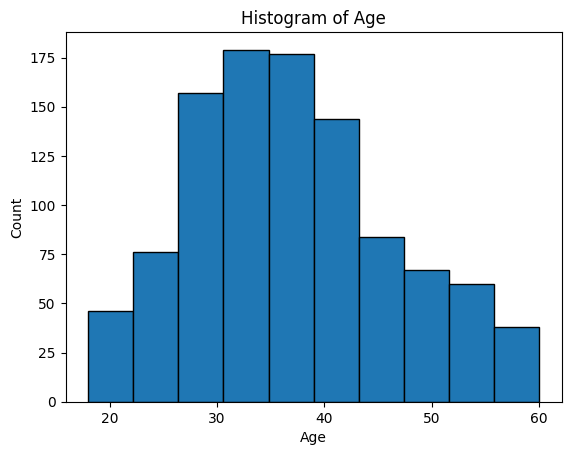

Most frequent age range appears around:
35


In [6]:
import matplotlib.pyplot as plt

plt.hist(df["Age"], bins=10, edgecolor='black')
plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

print("Most frequent age range appears around:")
print(df["Age"].value_counts().idxmax())


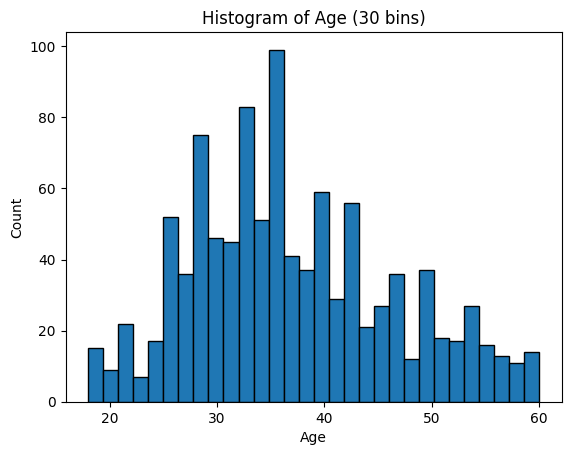

In [25]:
plt.hist(df["Age"], bins=30, edgecolor='black')
plt.title("Histogram of Age (30 bins)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


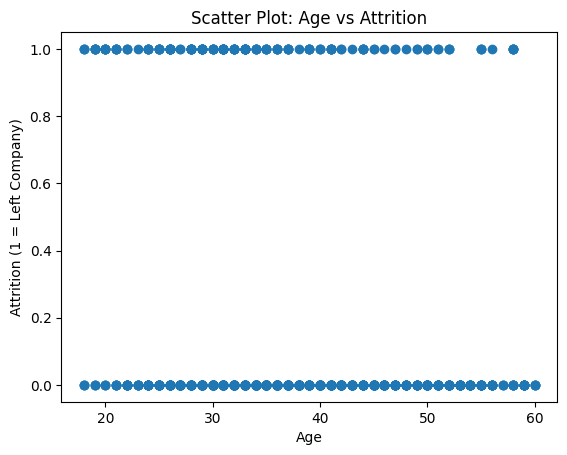

In [26]:
plt.scatter(df["Age"], df["Attrition"])
plt.title("Scatter Plot: Age vs Attrition")
plt.xlabel("Age")
plt.ylabel("Attrition (1 = Left Company)")
plt.show()


In [27]:
over_50 = df[df["Age"] > 50]
attrition_rate_over_50 = over_50["Attrition"].mean()

overall_attrition = df["Attrition"].mean()

print("Attrition rate for employees >50:", attrition_rate_over_50)
print("Overall attrition rate:", overall_attrition)


Attrition rate for employees >50: 0.1206896551724138
Overall attrition rate: 0.16731517509727625


Attrition
0.0    856
1.0    172
Name: count, dtype: int64


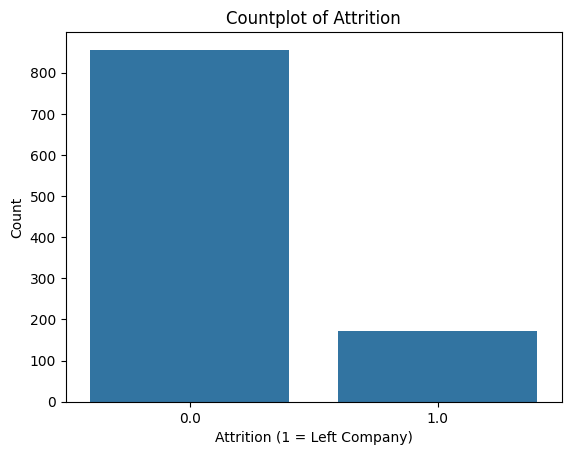

In [29]:
print(df["Attrition"].value_counts())
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="Attrition")
plt.title("Countplot of Attrition")
plt.xlabel("Attrition (1 = Left Company)")
plt.ylabel("Count")
plt.show()


In [30]:
pd.crosstab(df["Attrition"], df["BusinessTravel"])


BusinessTravel,Non-Travel,Travel_Frequently,Travel_Rarely
Attrition,,,
0.0,92,150,614
1.0,10,47,115


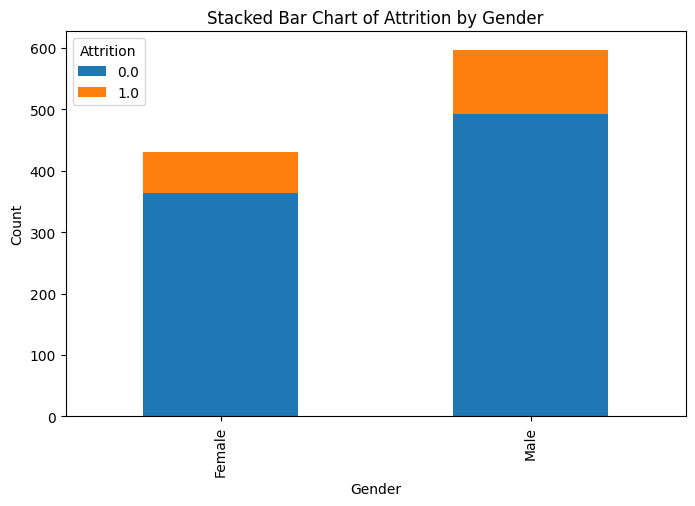

In [31]:
ct = pd.crosstab(df["Gender"], df["Attrition"])

ct.plot(kind="bar", stacked=True, figsize=(8,5))

plt.title("Stacked Bar Chart of Attrition by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Attrition")
plt.show()

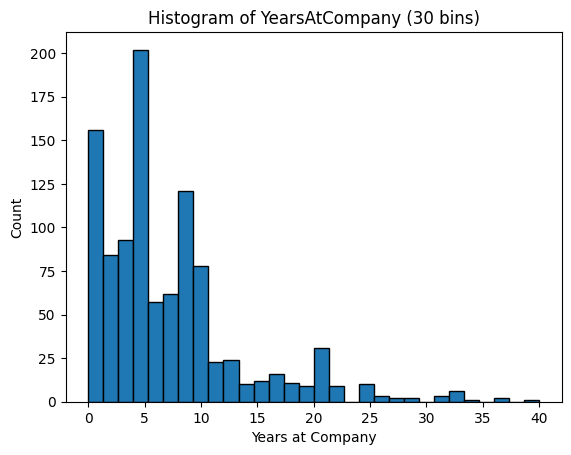

Skewness: 1.7724925350968725


In [7]:
plt.hist(df["YearsAtCompany"], bins=30, edgecolor='black')
plt.title("Histogram of YearsAtCompany (30 bins)")
plt.xlabel("Years at Company")
plt.ylabel("Count")
plt.show()

# Check if skewed
skew_value = df["YearsAtCompany"].skew()
print("Skewness:", skew_value)


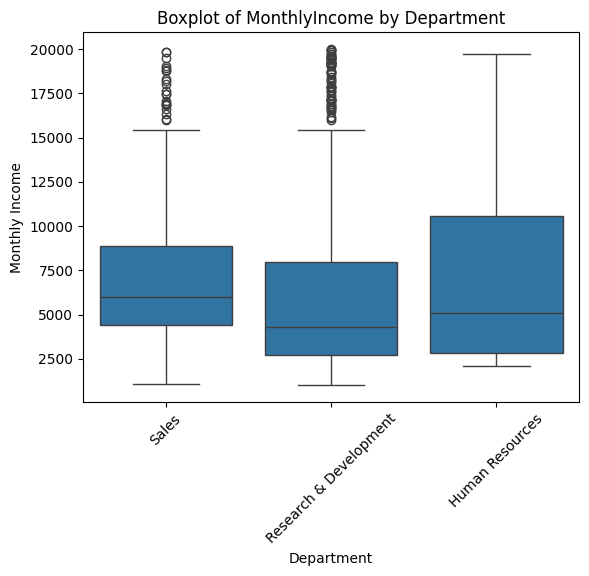

In [8]:
sns.boxplot(data=df, x="Department", y="MonthlyIncome")
plt.title("Boxplot of MonthlyIncome by Department")
plt.xlabel("Department")
plt.ylabel("Monthly Income")
plt.xticks(rotation=45)
plt.show()

In [9]:
outliers = {}

for dept in df["Department"].unique():
    dept_data = df[df["Department"] == dept]["MonthlyIncome"]

    Q1 = dept_data.quantile(0.25)
    Q3 = dept_data.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers[dept] = dept_data[(dept_data < lower) | (dept_data > upper)]

    print(f"\nDepartment: {dept}")
    print(f"Outliers:\n{outliers[dept]}")



Department: Sales
Outliers:
29     18947
119    16959
233    19517
235    16064
237    19068
263    16872
300    16015
417    18041
445    16835
466    16595
561    16856
616    16307
710    17444
741    18303
749    19845
755    17650
810    17465
861    17048
907    18213
913    18824
916    18789
918    19847
Name: MonthlyIncome, dtype: int64

Department: Research & Development
Outliers:
25      19094
45      19545
62      18740
106     18172
123     19537
        ...  
955     19187
1008    17328
1009    19701
1014    16422
1024    17169
Name: MonthlyIncome, Length: 69, dtype: int64

Department: Human Resources
Outliers:
Series([], Name: MonthlyIncome, dtype: int64)


In [10]:
job_counts = df["JobRole"].value_counts()
top_role = job_counts.idxmax()
top_count = job_counts.max()

print("Job role with highest number of employees:", top_role)
print("Number of employees in this role:", top_count)


Job role with highest number of employees: Sales Executive
Number of employees in this role: 223


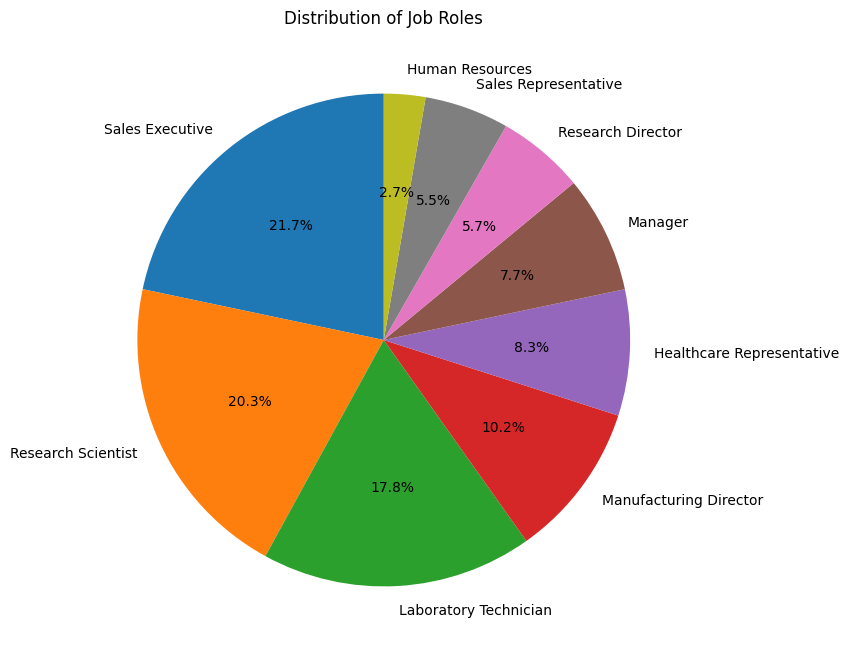

In [11]:
plt.figure(figsize=(8,8))
plt.pie(job_counts, labels=job_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Distribution of Job Roles")
plt.show()